In [4]:
# import libraries
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import VAR

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [5]:
# read in data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [6]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [7]:
# Replace inf values and Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

In [8]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [9]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [10]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [11]:
drop_cols = ['Ppt', 'RH', 'Windspeed', 'Winddirection']
df.drop(drop_cols, axis=1, inplace=True)

In [12]:
# Verify shape of data frame
df.shape

(72, 2)

In [13]:
lag_order=12
VAR_model = VAR(df)
results = VAR_model.fit(lag_order)

In [14]:
results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 14, Aug, 2023
Time:                     11:37:57
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    9.41250
Nobs:                     60.0000    HQIC:                   8.34989
Log likelihood:          -350.289    FPE:                    2380.72
AIC:                      7.66722    Det(Omega_mle):         1186.24
--------------------------------------------------------------------
Results for equation Tair
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const           11.320979        10.420552            1.086           0.277
L1.Tair          0.141747         0.210844            0.672           0.501
L1.Srad          0.035080         0.013346            2.629           0.009
L2.Ta

In [15]:
# Forecast 12 months
lag_order = results.k_ar

forecast = results.forecast(df.values[-lag_order:], lag_order)

# Convert the forecast array to a DataFrame
forecast_df = pd.DataFrame(forecast, columns=df.columns)

# Display the forecasted values
print("\nForecasted Values:")
print(forecast_df)


Forecasted Values:
         Tair        Srad
0    9.790871  137.385226
1   12.465148  156.705748
2   16.288722  160.684301
3   17.794755  227.733438
4   22.434714  249.633634
5   27.093866  282.965402
6   28.852506  288.767617
7   25.699293  273.541620
8   24.140341  201.168991
9   19.834514  165.675746
10  14.036829  128.914403
11  10.545324  123.151105


In [16]:
total_len = len(df.Tair)
forecast_x_values = range(total_len - len(forecast_df.Tair), total_len)

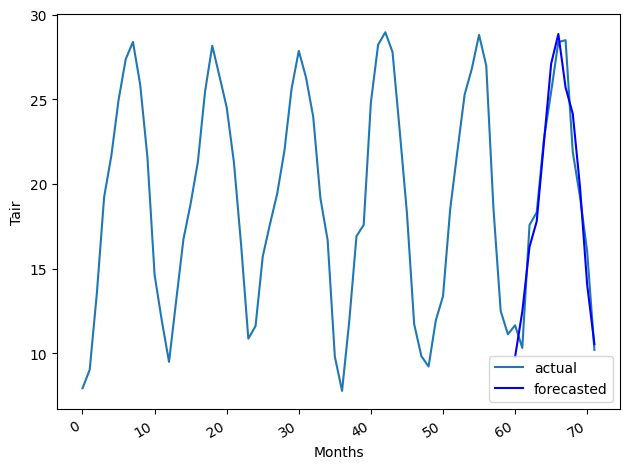

In [17]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Tair.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Tair, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Tair')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

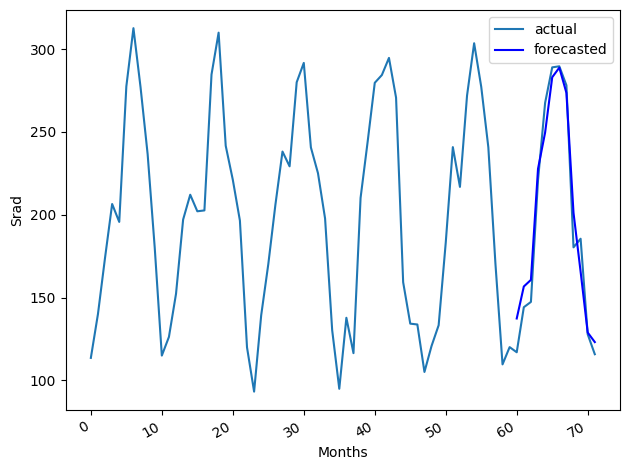

In [18]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Srad.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Srad, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Srad')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

In [19]:
mse_srad = mean_squared_error(forecast_df.Srad,df.Srad.tolist()[60:])
mse_srad

171.30173247735172

In [20]:
mse_tair = mean_squared_error(forecast_df.Tair,df.Tair.tolist()[60:])
mse_tair

2.521475440149503